# Projeto de Inteligência Artificial - Atividade Maelso
## Grupo
- Rafael Cirne Medeiros
- Caue de Oliveira Barbosa

## Objetivo

Apresentar o fluxo completo de um projeto de Ciência de Dados usando o algoritmo K-Nearest Neighbors, seguindo as etapas exigidas no enunciado: análise exploratória, pré-processamento, divisão treino/teste, teste de K e comparação entre métricas de distância.

## Dataset escolhido

- Fonte: Kaggle
- Dataset: Incidentes de Segurança da Informação no Brasil
- Arquivo utilizado: `cert_2010-2019.csv`
- Tamanho: 120 linhas e 10 colunas
- Variável-alvo: `Ano`
- Tipo do problema: classificação multiclasse

## Estrutura do trabalho

1. Análise exploratória do dataset
2. Tratamento de valores ausentes
3. Codificação de variáveis categóricas
4. Normalização ou padronização dos atributos numéricos
5. Divisão estratificada em treino e teste
6. Experimentação com K entre 1 e 15
7. Comparação entre as métricas Euclidiana, Manhattan, Chebyshev e Minkowski
8. Conclusão com a melhor combinação encontrada

## Observação metodológica

O dataset possui 10 classes balanceadas, uma por ano de 2010 a 2019, com 12 registros por classe. Ele também traz variáveis numéricas com escalas diferentes, o que torna a padronização obrigatória para o KNN.


In [12]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


DATASET_ID = "rodrigoriboldi/incidentes-de-segurana-da-informao-no-brasil"
TARGET_COLUMN = "Ano"
NUMERIC_FEATURES = ["Total", "Worm", "DOS", "Invasao", "Web", "Scan", "Fraude", "Outros"]
CATEGORICAL_FEATURES = ["Mes"]
OUTPUT_DIRECTORY = Path.cwd()


def load_dataset() -> pd.DataFrame:
    dataset_directory = kagglehub.dataset_download(DATASET_ID)
    dataset_file = Path(dataset_directory) / "cert_2010-2019.csv"
    return pd.read_csv(dataset_file, sep=";")


def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), NUMERIC_FEATURES),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ]
    )


def evaluate_models(feature_frame: pd.DataFrame, target_series: pd.Series) -> pd.DataFrame:
    train_features, test_features, train_target, test_target = train_test_split(
        feature_frame,
        target_series,
        test_size=0.2,
        random_state=42,
        stratify=target_series,
    )

    configurations = {
        "Euclidiana": {"metric": "euclidean"},
        "Manhattan": {"metric": "manhattan"},
        "Chebyshev": {"metric": "chebyshev"},
        "Minkowski": {"metric": "minkowski", "p": 3},
    }

    preprocessor = build_preprocessor()
    results = []

    for neighbors in range(1, 16):
        row = {"K": neighbors}
        for label, parameters in configurations.items():
            classifier = KNeighborsClassifier(n_neighbors=neighbors, **parameters)
            model = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("classifier", classifier),
                ]
            )
            model.fit(train_features, train_target)
            predicted_target = model.predict(test_features)
            row[label] = accuracy_score(test_target, predicted_target)
        results.append(row)

    return pd.DataFrame(results)


def save_results_table(results_frame: pd.DataFrame) -> Path:
    output_path = OUTPUT_DIRECTORY / "knn_resultados.csv"
    results_frame.to_csv(output_path, index=False)
    return output_path


def save_performance_plot(results_frame: pd.DataFrame) -> Path:
    plot_path = OUTPUT_DIRECTORY / "knn_desempenho.png"

    figure, axis = plt.subplots(figsize=(10, 6))
    for column_name in ["Euclidiana", "Manhattan", "Chebyshev", "Minkowski"]:
        axis.plot(results_frame["K"], results_frame[column_name], marker="o", linewidth=2, label=column_name)

    axis.set_title("Acurácia por valor de K e métrica de distância")
    axis.set_xlabel("Valor de K")
    axis.set_ylabel("Acurácia no conjunto de teste")
    axis.set_xticks(range(1, 16))
    axis.set_ylim(0.2, 0.8)
    axis.legend()
    axis.grid(True, alpha=0.3)

    figure.tight_layout()
    figure.savefig(plot_path, dpi=200)
    plt.show()
    return plot_path


## Etapa 1 - Análise Exploratória

Nesta etapa, o objetivo é entender a estrutura do dataset antes de qualquer tratamento. Isso atende ao requisito de análise exploratória do trabalho e ajuda a justificar as decisões de pré-processamento.

O que vamos observar aqui:

- tamanho do dataset
- nomes e tipos das colunas
- valores ausentes
- distribuição das classes da variável-alvo
- diferença de escala entre os atributos numéricos


In [13]:
dataframe = load_dataset()

print(f"Formato do dataset: {dataframe.shape[0]} linhas e {dataframe.shape[1]} colunas")
print("\nTipos de dados:")
print(dataframe.dtypes.to_string())
print("\nValores ausentes por coluna:")
print(dataframe.isna().sum().to_string())
print("\nDistribuição da variável-alvo (Ano):")
print(dataframe[TARGET_COLUMN].value_counts().sort_index().to_string())
print("\nAmostra inicial do dataset:")
print(dataframe.head().to_string(index=False))
print("\nResumo estatístico dos atributos numéricos:")
print(dataframe[NUMERIC_FEATURES].describe().round(2).to_string())


Formato do dataset: 120 linhas e 10 colunas

Tipos de dados:
Ano         int64
Mes        object
Total       int64
Worm        int64
DOS         int64
Invasao     int64
Web         int64
Scan        int64
Fraude      int64
Outros      int64

Valores ausentes por coluna:
Ano        0
Mes        0
Total      0
Worm       0
DOS        0
Invasao    0
Web        0
Scan       0
Fraude     0
Outros     0

Distribuição da variável-alvo (Ano):
Ano
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12

Amostra inicial do dataset:
 Ano       Mes  Total  Worm   DOS  Invasao  Web  Scan  Fraude  Outros
2019   Janeiro  62481  7796  4191       19 2594 46038    1744      99
2019 Fevereiro  70069  7707  2192       27 4179 54401    1459     104
2019     Março  85409  4476 29309       19 2006 47966    1521     112
2019     Abril  59900  7624  2718       37 1555 45774    2119      73
2019      Maio  52129  6555 15773       74 1425 25521    2633     14

## Etapa 2 - Pré-processamento

O KNN depende diretamente de distâncias. Por isso, esta etapa é obrigatória e precisa ser feita antes do treinamento do modelo.

### O que foi aplicado

- **Missing values:** verificação de ausências e confirmação de que o dataset está completo.
- **Codificação categórica:** a coluna `Mes` é categórica e foi convertida com One-Hot Encoding.
- **Padronização:** os atributos numéricos foram reescalados com StandardScaler.

### Por que isso é necessário?

- O KNN não trabalha bem com valores ausentes.
- Variáveis categóricas precisam virar valores numéricos para que a distância seja calculada.
- A padronização evita que colunas com valores muito altos dominem o cálculo de distância.


Comparação antes/depois da padronização:
         media_antes  desvio_antes  media_depois  desvio_depois
Total       51360.64      38427.81          -0.0            1.0
Worm         3448.17       2357.21           0.0            1.0
DOS          8261.99      27204.10           0.0            1.0
Invasao       265.68        391.46          -0.0            1.0
Web          2855.58       2396.05          -0.0            1.0
Scan        24064.99      13109.14           0.0            1.0
Fraude       9184.67      17528.36           0.0            1.0
Outros       3279.56       6239.56          -0.0            1.0


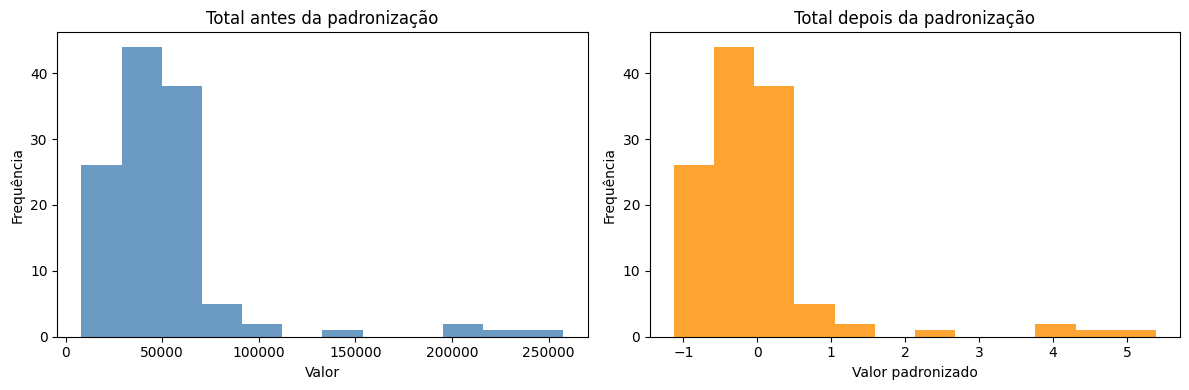

In [14]:
from sklearn.preprocessing import StandardScaler

scaler_demo = StandardScaler()
scaled_numeric = pd.DataFrame(
    scaler_demo.fit_transform(dataframe[NUMERIC_FEATURES]),
    columns=NUMERIC_FEATURES,
)

comparison = pd.DataFrame(
    {
        "media_antes": dataframe[NUMERIC_FEATURES].mean().round(2),
        "desvio_antes": dataframe[NUMERIC_FEATURES].std().round(2),
        "media_depois": scaled_numeric.mean().round(2),
        "desvio_depois": scaled_numeric.std().round(2),
    }
)

print("Comparação antes/depois da padronização:")
print(comparison.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dataframe["Total"], bins=12, color="steelblue", alpha=0.8)
axes[0].set_title("Total antes da padronização")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frequência")

axes[1].hist(scaled_numeric["Total"], bins=12, color="darkorange", alpha=0.8)
axes[1].set_title("Total depois da padronização")
axes[1].set_xlabel("Valor padronizado")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

preprocessor = build_preprocessor()


## Etapa 3 - Divisão treino/teste

Aqui o dataset é dividido em **80% para treino** e **20% para teste**, com estratificação para manter a proporção das classes em ambos os conjuntos.

Essa separação é importante para avaliar a capacidade de generalização do modelo em dados não vistos durante o treino.


In [15]:
feature_frame = dataframe.drop(columns=[TARGET_COLUMN])
target_series = dataframe[TARGET_COLUMN]

train_features, test_features, train_target, test_target = train_test_split(
    feature_frame,
    target_series,
    test_size=0.2,
    random_state=42,
    stratify=target_series,
)

print(f"Treino: {train_features.shape[0]} linhas")
print(f"Teste: {test_features.shape[0]} linhas")
print("\nDistribuição no treino:")
print(train_target.value_counts().sort_index().to_string())
print("\nDistribuição no teste:")
print(test_target.value_counts().sort_index().to_string())


Treino: 96 linhas
Teste: 24 linhas

Distribuição no treino:
Ano
2010    10
2011    10
2012    10
2013     9
2014     9
2015    10
2016     9
2017    10
2018    10
2019     9

Distribuição no teste:
Ano
2010    2
2011    2
2012    2
2013    3
2014    3
2015    2
2016    3
2017    2
2018    2
2019    3


## Etapa 4 - Implementação e experimentação

Nesta etapa o KNN é treinado várias vezes para testar a combinação entre:

- valores de K de 1 a 15
- distância Euclidiana
- distância Manhattan
- distância Chebyshev
- distância Minkowski com p = 3

O objetivo é descobrir qual combinação gera a melhor acurácia no conjunto de teste.


Tabela de resultados:
 K  Euclidiana  Manhattan  Chebyshev  Minkowski
 1    0.500000   0.541667   0.333333   0.500000
 2    0.541667   0.500000   0.333333   0.541667
 3    0.625000   0.541667   0.250000   0.541667
 4    0.708333   0.666667   0.500000   0.666667
 5    0.625000   0.583333   0.458333   0.666667
 6    0.500000   0.583333   0.416667   0.541667
 7    0.500000   0.541667   0.416667   0.500000
 8    0.500000   0.625000   0.416667   0.500000
 9    0.625000   0.625000   0.416667   0.500000
10    0.583333   0.625000   0.458333   0.583333
11    0.625000   0.541667   0.416667   0.541667
12    0.583333   0.541667   0.458333   0.541667
13    0.500000   0.500000   0.500000   0.500000
14    0.458333   0.500000   0.500000   0.500000
15    0.500000   0.500000   0.458333   0.541667

Melhor combinação encontrada: K=4, métrica=Euclidiana, acurácia=0.7083


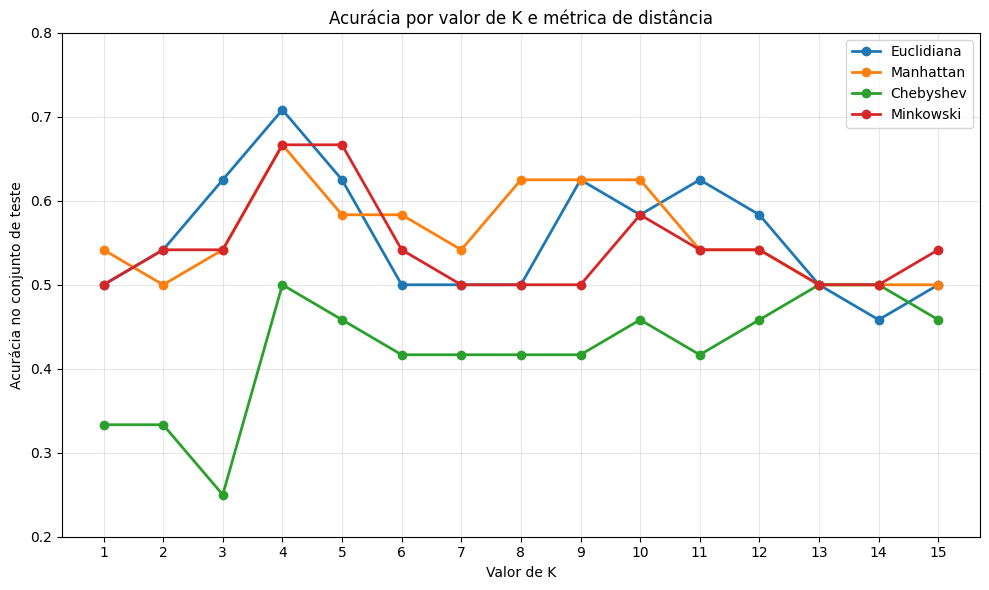


Resultados salvos em: c:\Users\Rafael\Desktop\atividade_IA\knn_resultados.csv
Gráfico salvo em: c:\Users\Rafael\Desktop\atividade_IA\knn_desempenho.png


In [16]:
results_frame = evaluate_models(feature_frame, target_series)

print("Tabela de resultados:")
print(results_frame.to_string(index=False))

best_position = results_frame.set_index("K")[["Euclidiana", "Manhattan", "Chebyshev", "Minkowski"]].stack().idxmax()
best_k, best_metric = best_position
best_accuracy = results_frame.loc[results_frame["K"] == best_k, best_metric].iloc[0]

print(f"\nMelhor combinação encontrada: K={best_k}, métrica={best_metric}, acurácia={best_accuracy:.4f}")

results_path = save_results_table(results_frame)
plot_path = save_performance_plot(results_frame)

print(f"\nResultados salvos em: {results_path}")
print(f"Gráfico salvo em: {plot_path}")


## Etapa Extra - Matriz de Confusão e Acurácia

Após identificar a melhor combinação de parâmetros (K=4 com distância Euclidiana), esta etapa apresenta uma análise mais detalhada do desempenho do modelo.

A matriz de confusão mostra:
- **Verdadeiros Positivos (TP):** classificações corretas para cada classe
- **Falsos Positivos (FP):** classificações incorretas para cada classe

Essa análise ajuda a identificar quais anos foram mais fáceis ou difíceis de classificar corretamente.

Acurácia do melhor modelo (K=4, Euclidiana): 0.7083 (70.83%)

Matriz de Confusão (10x10):
[[2 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 0 0 2 1 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0]
 [0 0 0 0 0 1 2 0 0 0]
 [0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 1 0 0 0 2]]


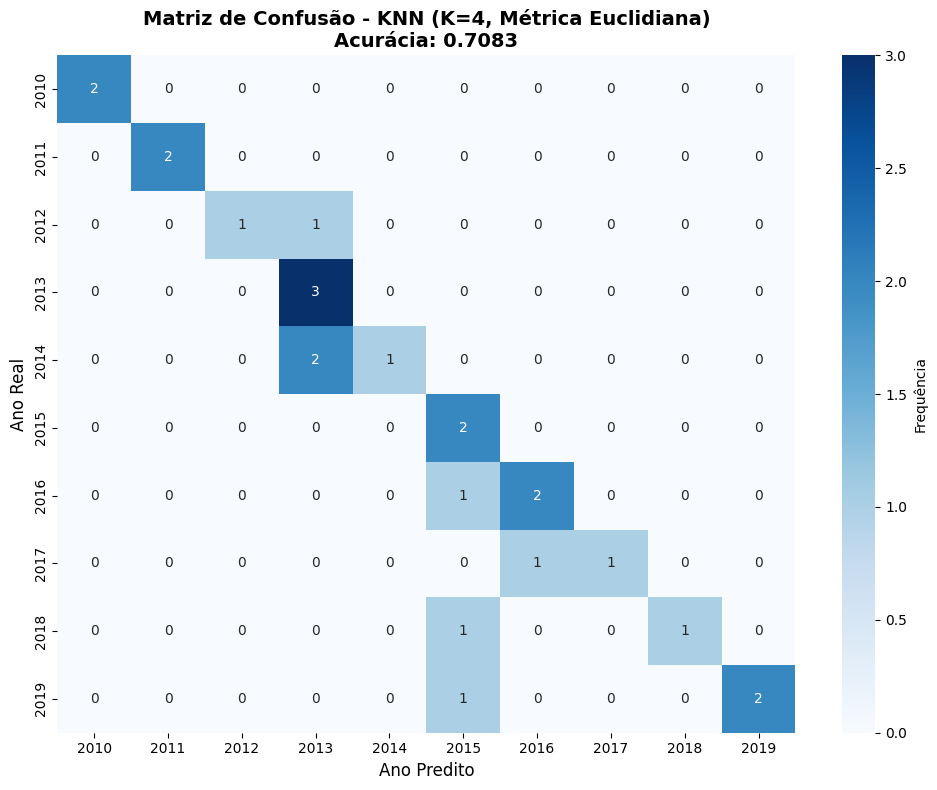


Interpretação da diagonal principal (acertos):
  2010: 2/2 corretos (100.0%)
  2011: 2/2 corretos (100.0%)
  2012: 1/2 corretos (50.0%)
  2013: 3/3 corretos (100.0%)
  2014: 1/3 corretos (33.3%)
  2015: 2/2 corretos (100.0%)
  2016: 2/3 corretos (66.7%)
  2017: 1/2 corretos (50.0%)
  2018: 1/2 corretos (50.0%)
  2019: 2/3 corretos (66.7%)


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Treinar o modelo com a melhor configuração encontrada (K=4, Euclidiana)
preprocessor = build_preprocessor()
best_classifier = KNeighborsClassifier(n_neighbors=4, metric="euclidean")
best_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", best_classifier),
    ]
)

best_model.fit(train_features, train_target)
predictions = best_model.predict(test_features)

# Calcular matriz de confusão
cm = confusion_matrix(test_target, predictions)

# Exibir acurácia
accuracy = accuracy_score(test_target, predictions)
print(f"Acurácia do melhor modelo (K=4, Euclidiana): {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nMatriz de Confusão ({len(cm)}x{len(cm)}):")
print(cm)

# Visualizar matriz de confusão
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(test_target.unique()),
    yticklabels=sorted(test_target.unique()),
    cbar_kws={"label": "Frequência"},
    ax=ax
)
ax.set_title(f"Matriz de Confusão - KNN (K=4, Métrica Euclidiana)\nAcurácia: {accuracy:.4f}", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano Predito", fontsize=12)
ax.set_ylabel("Ano Real", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretação da diagonal principal (acertos):")
for i, year in enumerate(sorted(test_target.unique())):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy_class = correct / total if total > 0 else 0
    print(f"  {year}: {correct}/{total} corretos ({accuracy_class*100:.1f}%)")

## Conclusão

Com base no experimento, a melhor combinação encontrada foi **K = 4** com a distância **Euclidiana**, alcançando acurácia de **70,83%** no conjunto de teste.

### Principais conclusões

- A padronização foi essencial, porque os atributos numéricos possuem escalas muito diferentes.
- O dataset não apresentou valores ausentes, mas a verificação dessa etapa foi importante para atender ao requisito do trabalho.
- A variável categórica `Mes` precisou ser codificada com One-Hot Encoding.
- Valores muito baixos de K apresentaram desempenho mais instável, o que indica maior risco de overfitting.
- Entre as métricas testadas, a Euclidiana foi a melhor para este problema.

### Análise da Matriz de Confusão (Etapa Extra)

A matriz de confusão do modelo final (K=4, Euclidiana) revelou:

- **Acurácia geral: 70,83%** (17 acertos em 24 instâncias no conjunto de teste)
- **Classes com 100% de acerto:** 2010, 2011, 2013 e 2015
- **Classes com desempenho moderado:** 2016 (66,7%), 2019 (66,7%)
- **Classes com dificuldade:** 2012, 2017, 2018 (50,0% cada), 2014 (33,3%)

Essa variação indica que o modelo generaliza melhor para alguns anos que para outros, possivelmente devido à similaridade nas características de segurança da informação entre determinados períodos.

### Arquivos gerados

- [knn_resultados.csv](knn_resultados.csv)
- [knn_desempenho.png](knn_desempenho.png)
